# Resampling


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pooch

from batread.dataset import Dataset

from batcamp import Octree
from batcamp import OctreeInterpolator


## Build Dataset, Octree, and Interpolator

The file below is a Cartesian 3D sample. We build the tree once and reuse it for all queries.


In [2]:
data_path = pooch.retrieve(
    url="https://zenodo.org/records/7110555/files/run-Sun-G2211.tar.gz",
    known_hash="c31a32aab08cc20d5b643bba734fd7220e6b369e691f55f88a3a08cc5b2a2136",
    progressbar=False,
    processor=pooch.Untar(members=["run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt"]),
)
if isinstance(data_path, (list, tuple)):
    data_path = data_path[0]
data_path


'../sample_data/3d__var_2_n00006003.plt'

In [3]:
ds = Dataset.from_file(str(data_path))
print(ds)
xyz_span = [ds.span(f"{c} [R]") for c in 'XYZ']

rho_name = next(name for name in ds.variables if name.startswith('Rho '))
interp = OctreeInterpolator(ds, [rho_name])
print(interp)


Title:     'BATSRUS: 3D Data, 2000/01/30 00:00:00.000'
Zone:      '3D   N=0006003'
Variables: 4
Shape:     (21069, 4)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]'].


OctreeInterpolator(tree_coord=xyz, fields=1[Rho [g/cm^3]], n_points=21069, n_cells=18432, n_components=1)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Resample to XY Plane (z=0)

In [4]:
xmin, xmax = ds.span("X [R]")
ymin, ymax = ds.span("Y [R]")

nx, ny = 300, 300
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(x, y, indexing='xy')
zz = np.zeros_like(xx)
q = np.column_stack((xx.ravel(), yy.ravel(), zz.ravel()))

rho_xy, cell_xy = interp(q, query_coord='xyz', return_cell_ids=True)
rho_xy = np.asarray(rho_xy, dtype=float).reshape(ny, nx)
cell_xy = np.asarray(cell_xy, dtype=int).reshape(ny, nx)
valid_xy = (cell_xy >= 0) & (rho_xy > 0.0)
log_rho_xy = np.full_like(rho_xy, np.nan, dtype=float)
log_rho_xy[valid_xy] = np.log10(rho_xy[valid_xy])
print('xy valid fraction:', float(valid_xy.mean()))


xy valid fraction: 1.0


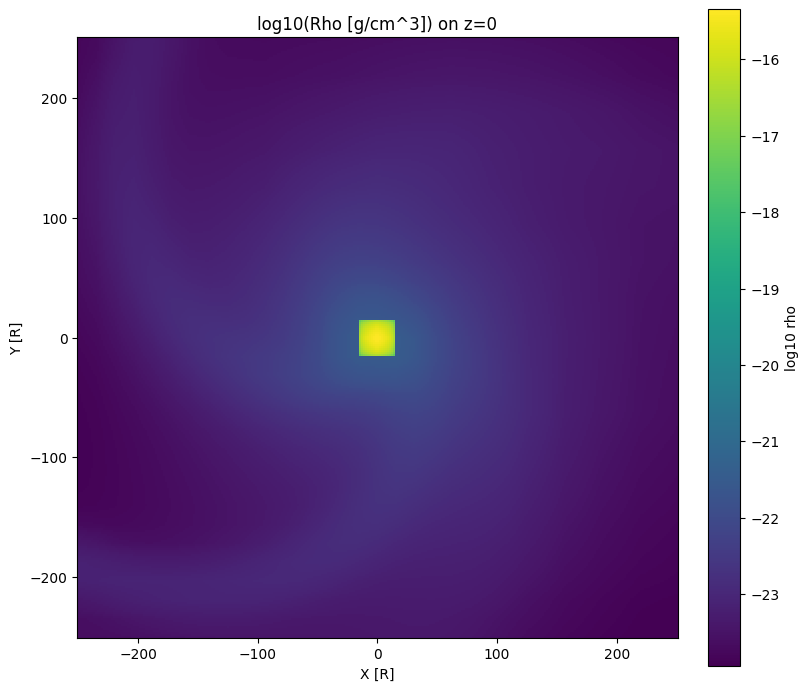

In [5]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
im = ax.pcolormesh(xx, yy, log_rho_xy, shading='auto', cmap='viridis')
ax.set_xlabel('X [R]')
ax.set_ylabel('Y [R]')
ax.set_title(f'log10({rho_name}) on z=0')
ax.set_aspect('equal')
cb = fig.colorbar(im, ax=ax)
cb.set_label('log10 rho')
plt.show()


## Resample to an Inclined Plane

Resolution: `320 x 240` points (dense enough for smooth structure, still fast).


In [6]:
# Plane basis: normal is intentionally not axis-aligned.
normal = np.array([0.45, -0.20, 1.00], dtype=float)
normal /= np.linalg.norm(normal)

ref = np.array([0.0, 0.0, 1.0], dtype=float)
if abs(float(np.dot(normal, ref))) > 0.95:
    ref = np.array([1.0, 0.0, 0.0], dtype=float)

e_u = np.cross(normal, ref)
e_u /= np.linalg.norm(e_u)
e_v = np.cross(normal, e_u)

center = np.array([ds.center(f'{c} [R]') for c in 'XYZ'], dtype=float)
span = np.array([ds.span(f'{c} [R]') for c in 'XYZ'], dtype=float)
offset = np.array([0.10, -0.05, 0.08]) * center
plane_center = center + offset

nu, nv = 320, 240
half_width_u = 0.40 * float(np.linalg.norm(xyz_span))
half_width_v = 0.28 * float(np.linalg.norm(xyz_span))

u = np.linspace(-half_width_u, half_width_u, nu)
v = np.linspace(-half_width_v, half_width_v, nv)
uu, vv = np.meshgrid(u, v, indexing='xy')

plane_xyz = (
    plane_center[None, None, :]
    + uu[..., None] * e_u[None, None, :]
    + vv[..., None] * e_v[None, None, :]
).reshape(-1, 3)

rho_plane, cell_plane = interp(plane_xyz, query_coord='xyz', return_cell_ids=True)
rho_plane = np.asarray(rho_plane, dtype=float).reshape(nv, nu)
cell_plane = np.asarray(cell_plane, dtype=int).reshape(nv, nu)

valid_plane = (cell_plane >= 0) & (rho_plane > 0.0)
log_rho_plane = np.full_like(rho_plane, np.nan, dtype=float)
log_rho_plane[valid_plane] = np.log10(rho_plane[valid_plane])

print('plane valid fraction:', float(valid_plane.mean()))


plane valid fraction: 0.9753385416666667


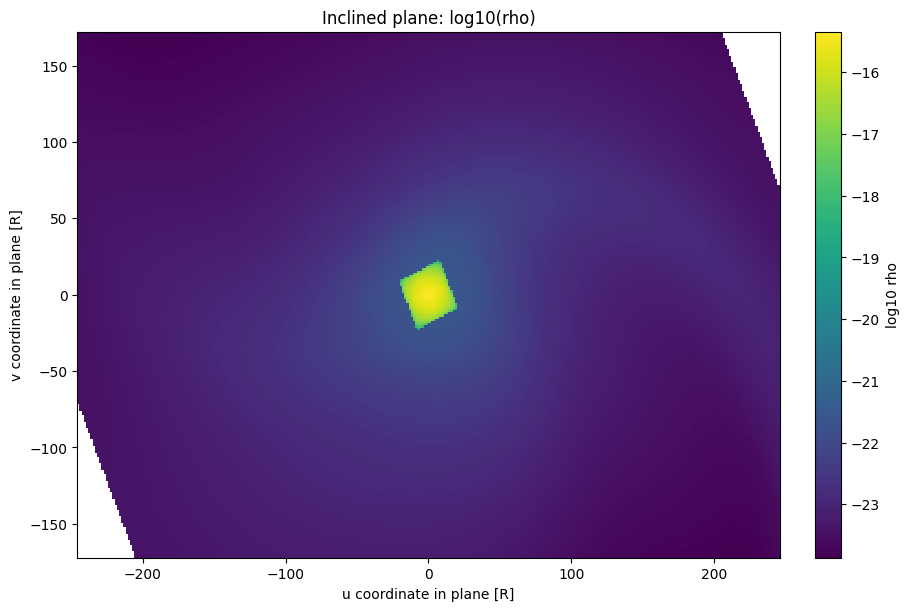

In [7]:
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
im = ax.pcolormesh(uu, vv, log_rho_plane, shading='auto', cmap='viridis')
ax.set_xlabel('u coordinate in plane [R]')
ax.set_ylabel('v coordinate in plane [R]')
ax.set_title('Inclined plane: log10(rho)')
cb = fig.colorbar(im, ax=ax)
cb.set_label('log10 rho')
plt.show()


## Resample to a Sphere

Resolution: `180 x 360` (`theta x phi`) points.


In [8]:
r_sphere = 80

n_theta, n_phi = 180, 360
theta = np.linspace(0.0, np.pi, n_theta)
phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)
pp, tt = np.meshgrid(phi, theta, indexing='xy')

x_s = r_sphere * np.sin(tt) * np.cos(pp)
y_s = r_sphere * np.sin(tt) * np.sin(pp)
z_s = r_sphere * np.cos(tt)

sphere_xyz = np.column_stack((x_s.ravel(), y_s.ravel(), z_s.ravel()))
rho_sphere, cell_sphere = interp(
    sphere_xyz, 
    return_cell_ids=True,
    )
rho_sphere = np.asarray(rho_sphere, dtype=float).reshape(n_theta, n_phi)
cell_sphere = np.asarray(cell_sphere, dtype=int).reshape(n_theta, n_phi)

valid_sphere = (cell_sphere >= 0) & (rho_sphere > 0.0)
log_rho_sphere = np.full_like(rho_sphere, np.nan, dtype=float)
log_rho_sphere[valid_sphere] = np.log10(rho_sphere[valid_sphere])

print('sphere radius [R]:', r_sphere)
print('sphere valid fraction:', float(valid_sphere.mean()))


sphere radius [R]: 80
sphere valid fraction: 1.0


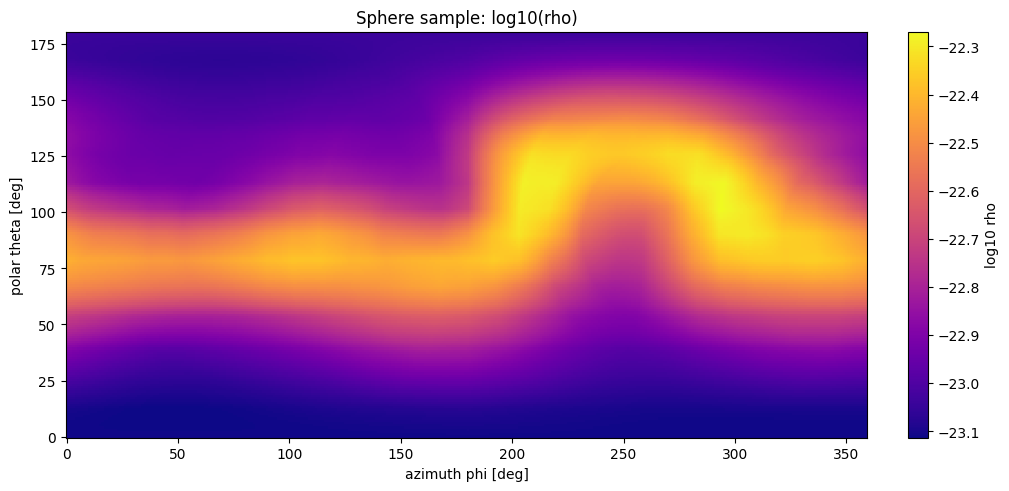

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.pcolormesh(np.degrees(pp), np.degrees(tt), log_rho_sphere, shading='auto', cmap='plasma')
ax.set_xlabel('azimuth phi [deg]')
ax.set_ylabel('polar theta [deg]')
ax.set_title('Sphere sample: log10(rho)')
cb = fig.colorbar(im, ax=ax)
cb.set_label('log10 rho')
plt.show()
